# Problem Set 9: Project Genesis – The Autonomous Engineer

In Module 2, you unlocked the power of high-performance physics engines using JAX. In Module 3, you connected these simulators to cognitive models (local Gemma 4 models). But until now, the human has always been the bottleneck—analyzing the graphs, adjusting parameters, and clicking 'Run' again.

Today, we cross the threshold of autonomy. You will build the **Silicon Cartographer**. Your mission is to delegate the entire exploration of a JAX-accelerated Mandelbrot simulation to an agentic loop. The agent will act as an experimental scientist: starting from a global view, it will dynamically zoom in, analyze boundaries, calculate entropy, and refine its search coordinates to locate specific fractal details (like "Seahorse Valley").

We will implement this in three distinct phases:
1. **Manual Prompting (Pure Model)**: Experience the coordination overhead of manual human-in-the-loop parameter selection.
2. **Native Tool Calling (Model + Tools)**: Implement declarative Function Calling schemas and construct an automated execution pipeline.
3. **Capsule Packaging: The Gemma-Skill (Model + Tools + Skills)**: Structure the agent architecture into a modular, shareable, and self-contained Gemma-Skill unit.

Let's build!

## Exercise 1: The Manual Cartographer (Pure Model)

We start by running a JAX-accelerated Mandelbrot simulator. In this exercise, the agent only reasons in natural language, and the human is responsible for copying coordinates and running the code.

Below is the JAX-accelerated Mandelbrot simulation code that calculates the fractal and returns complexity metrics (Shannon Entropy of escape times and boundary pixel ratio).

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# JAX Mandelbrot Core Kernel
@jax.jit
def mandelbrot_kernel(c, max_iters):
    def body_fn(val):
        z, count, active, iteration = val

        next_z = jnp.where(active, z**2 + c, z)
        next_active = active & (jnp.abs(next_z) <= 2.0)
        next_count = jnp.where(next_active, count + 1, count)

        return next_z, next_count, next_active, iteration + 1

    def cond_fn(val):
        _, _, active, iteration = val
        return jnp.any(active) & (iteration < max_iters)

    z = jnp.zeros_like(c)
    count = jnp.zeros_like(c, dtype=jnp.int32)
    active = jnp.ones_like(c, dtype=jnp.bool_)
    iteration = jnp.array(0, dtype=jnp.int32)

    _, final_counts, _, _ = jax.lax.while_loop(
        cond_fn,
        body_fn,
        (z, count, active, iteration),
    )

    return final_counts

def run_simulation(center_real, center_imag, zoom, resolution=400, max_iterations=500):
    # Map resolution coordinates to complex plane
    width, height = resolution, resolution
    r = jnp.linspace(center_real - 1.5 / zoom, center_real + 1.5 / zoom, width)
    i = jnp.linspace(center_imag - 1.5 / zoom, center_imag + 1.5 / zoom, height)
    R, I = jnp.meshgrid(r, i)
    C = R + 1j * I

    # Execute high-performance calculation on accelerator
    counts = mandelbrot_kernel(C.flatten(), max_iterations)
    counts = counts.reshape((height, width))

    # Calculate Shannon Entropy of escape times
    hist, _ = jnp.histogram(counts, bins=20)
    hist_prob = hist / jnp.sum(hist)
    hist_prob = jnp.where(hist_prob > 0, hist_prob, 1.0)  # Avoid log(0)
    entropy = -jnp.sum(hist_prob * jnp.log(hist_prob))

    # Calculate Boundary Complexity (ratio of boundary pixels)
    boundary_pixels = jnp.sum((counts > 0) & (counts < max_iterations))
    boundary_ratio = boundary_pixels / (width * height)

    return counts, {
        "entropy": float(entropy),
        "boundary_complexity": float(boundary_ratio),
        "center_real": float(center_real),
        "center_imag": float(center_imag),
        "zoom": float(zoom),
        "max_iterations": int(max_iterations)
    }

Simulation Metrics: {'entropy': 0.8722120523452759, 'boundary_complexity': 0.6235374808311462, 'center_real': -0.5, 'center_imag': 0.0, 'zoom': 1.5, 'max_iterations': 500}


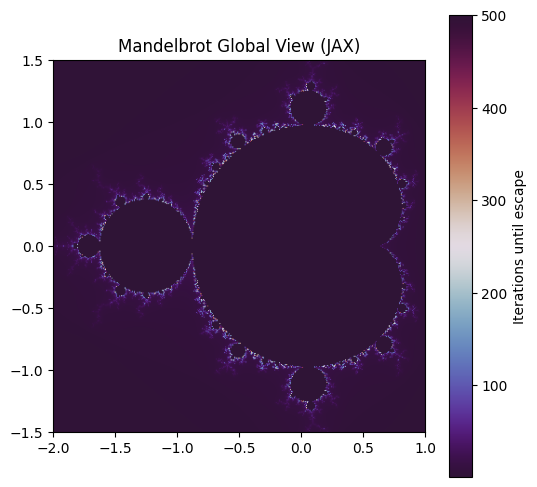

In [2]:
# Test execution at global view
counts, metrics = run_simulation(center_real=-0.5, center_imag=0.0, zoom=1.5)
print("Simulation Metrics:", metrics)

plt.figure(figsize=(6, 6))
plt.imshow(counts, cmap='twilight_shifted', extent=[-2, 1, -1.5, 1.5])
plt.colorbar(label='Iterations until escape')
plt.title('Mandelbrot Global View (JAX)')
plt.show()

In [3]:
import os
from google import genai


api_key = os.environ.get("GEMINI_API_KEY")


print("GEMINI_API_KEY vorhanden:", bool(os.environ.get("GEMINI_API_KEY")))
print("GOOGLE_API_KEY vorhanden:", bool(os.environ.get("GOOGLE_API_KEY")))

if not api_key:
    raise RuntimeError(
        "GEMINI_API_KEY wurde nicht gefunden. "
        "Setze ihn vor dem Start von VS Code in PowerShell."
    )

client = genai.Client(api_key=api_key)

manual_prompt = f"""
You are the Silicon Cartographer, an experimental scientist exploring the Mandelbrot set.

Current simulation metrics:
{metrics}

Goal:
Navigate from the global Mandelbrot view toward the region known as Seahorse Valley.

Suggest the next simulation parameters.

Rules:
- Increase the zoom noticeably, but do not jump directly to the final target.
- Keep the next point near an interesting Mandelbrot boundary.
- Return exactly these three lines:

CENTER_REAL: <number>
CENTER_IMAG: <number>
ZOOM: <number>

Do not include any additional explanation.
"""

response = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents=manual_prompt,
)

print("=== MODEL SUGGESTION – STEP 1 ===")
print(response.text)

GEMINI_API_KEY vorhanden: True
GOOGLE_API_KEY vorhanden: False
=== MODEL SUGGESTION – STEP 1 ===
CENTER_REAL: -0.743643
CENTER_IMAG: 0.131825
ZOOM: 150.0


=== SIMULATION METRICS – STEP 1 ===
{'entropy': 1.9110857248306274, 'boundary_complexity': 0.7098374962806702, 'center_real': -0.743643, 'center_imag': 0.131825, 'zoom': 150.0, 'max_iterations': 500}


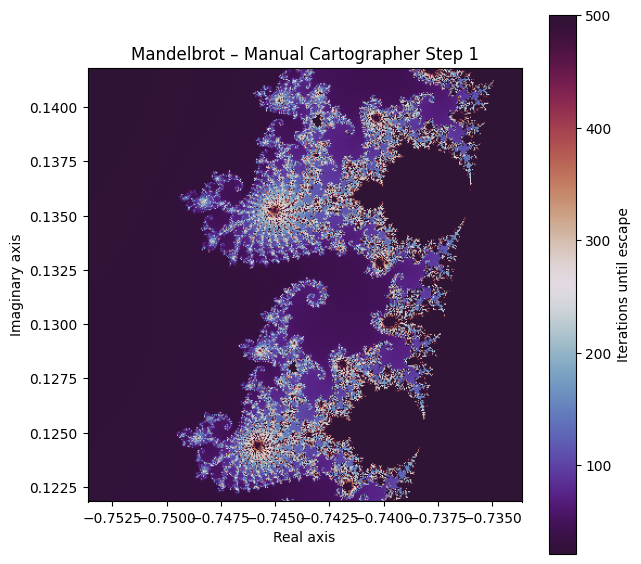

In [4]:
# Manual simulation step 1 using the coordinates suggested by Gemini

step_1_center_real = -0.743643
step_1_center_imag = 0.131825
step_1_zoom = 150.0

counts_step_1, metrics_step_1 = run_simulation(
    center_real=step_1_center_real,
    center_imag=step_1_center_imag,
    zoom=step_1_zoom,
    resolution=400,
    max_iterations=500,
)

print("=== SIMULATION METRICS – STEP 1 ===")
print(metrics_step_1)

# Calculate the visible coordinate range for the current zoom
real_min = step_1_center_real - 1.5 / step_1_zoom
real_max = step_1_center_real + 1.5 / step_1_zoom
imag_min = step_1_center_imag - 1.5 / step_1_zoom
imag_max = step_1_center_imag + 1.5 / step_1_zoom

plt.figure(figsize=(7, 7))
plt.imshow(
    counts_step_1,
    cmap="twilight_shifted",
    extent=[real_min, real_max, imag_min, imag_max],
    origin="lower",
)
plt.colorbar(label="Iterations until escape")
plt.xlabel("Real axis")
plt.ylabel("Imaginary axis")
plt.title("Mandelbrot – Manual Cartographer Step 1")
plt.show()

In [5]:
manual_prompt_step_2 = f"""
You are the Silicon Cartographer, an experimental scientist exploring the Mandelbrot set.

The previous global simulation was followed by a manual zoom toward Seahorse Valley.

Current simulation metrics:
{metrics_step_1}

Current parameters:
CENTER_REAL: {step_1_center_real}
CENTER_IMAG: {step_1_center_imag}
ZOOM: {step_1_zoom}

Goal:
Refine the search further into a visually complex boundary inside Seahorse Valley.

Use the entropy and boundary complexity to decide whether the center should be adjusted.
Increase the zoom substantially, but keep the coordinates near the current boundary.

Return exactly these three lines:

CENTER_REAL: <number>
CENTER_IMAG: <number>
ZOOM: <number>

Do not include additional explanation.
"""

response_step_2 = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents=manual_prompt_step_2,
)

print("=== MODEL SUGGESTION – STEP 2 ===")
print(response_step_2.text)

=== MODEL SUGGESTION – STEP 2 ===
CENTER_REAL: -0.74364388703
CENTER_IMAG: 0.13182525367
ZOOM: 50000.0


=== SIMULATION METRICS – STEP 2 ===
{'entropy': 2.1849472522735596, 'boundary_complexity': 0.9840375185012817, 'center_real': -0.74364388703, 'center_imag': 0.13182525367, 'zoom': 50000.0, 'max_iterations': 500}


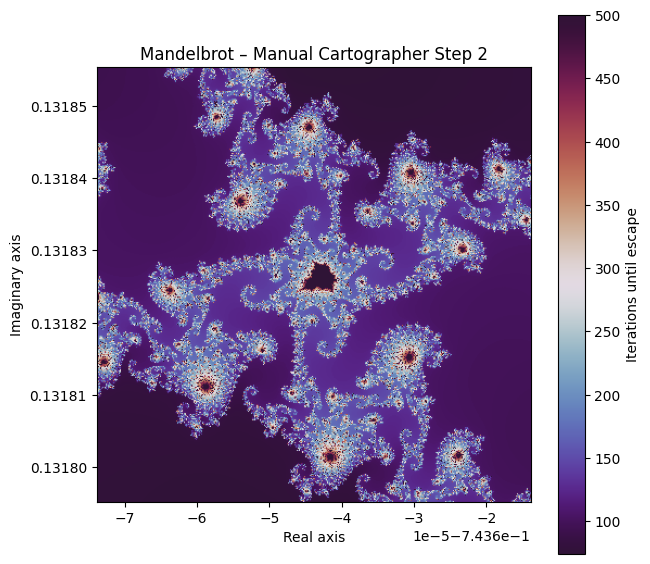

In [6]:
# Manual simulation step 2 using the coordinates suggested by Gemini

step_2_center_real = -0.74364388703
step_2_center_imag = 0.13182525367
step_2_zoom = 50000.0

counts_step_2, metrics_step_2 = run_simulation(
    center_real=step_2_center_real,
    center_imag=step_2_center_imag,
    zoom=step_2_zoom,
    resolution=400,
    max_iterations=500,
)

print("=== SIMULATION METRICS – STEP 2 ===")
print(metrics_step_2)

real_min = step_2_center_real - 1.5 / step_2_zoom
real_max = step_2_center_real + 1.5 / step_2_zoom
imag_min = step_2_center_imag - 1.5 / step_2_zoom
imag_max = step_2_center_imag + 1.5 / step_2_zoom

plt.figure(figsize=(7, 7))
plt.imshow(
    counts_step_2,
    cmap="twilight_shifted",
    extent=[real_min, real_max, imag_min, imag_max],
    origin="lower",
)
plt.colorbar(label="Iterations until escape")
plt.xlabel("Real axis")
plt.ylabel("Imaginary axis")
plt.title("Mandelbrot – Manual Cartographer Step 2")
plt.show()

In [7]:
manual_prompt_step_3 = f"""
You are the Silicon Cartographer, an experimental scientist exploring the Mandelbrot set.

Current simulation metrics:
{metrics_step_2}

Current parameters:
CENTER_REAL: {step_2_center_real}
CENTER_IMAG: {step_2_center_imag}
ZOOM: {step_2_zoom}

Goal:
Perform one final manual refinement step inside Seahorse Valley.

Use the entropy and boundary complexity to decide whether the current center is still on a complex boundary.
Suggest one final set of coordinates and zoom parameters.

Rules:
- Keep the coordinates close to the current location.
- Increase the zoom again.
- Return exactly these three lines:

CENTER_REAL: <number>
CENTER_IMAG: <number>
ZOOM: <number>

Do not include additional explanation.
"""

response_step_3 = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents=manual_prompt_step_3,
)

print("=== MODEL SUGGESTION – STEP 3 ===")
print(response_step_3.text)

=== MODEL SUGGESTION – STEP 3 ===
CENTER_REAL: -0.743643887034
CENTER_IMAG: 0.131825253672
ZOOM: 250000.0


### Task:
1. Write a prompt to your LLM (using the Gemini API or a local Gemma model).
2. Feed it the `metrics` dictionary obtained above.
3. Ask the model to suggest coordinates to navigate toward the **"Seahorse Valley"** ($c \approx -0.7436, 0.1318i$) and increase zoom.
4. Manually run the simulation with the suggested coordinates, extract the new metrics, and pass them back to the model for another iteration. Do this for 3 steps.

**Question:** What are the latency and usability limitations of this manual human-in-the-loop coordination compared to automated loops?

Die manuelle Exploration zeigt einen deutlichen Koordinationsaufwand. Ausgehend von der globalen Ansicht mit einem Zoomfaktor von 1.5 und einer Entropie von ungefähr 0.87 mussten die Simulationsmetriken zunächst manuell an das Sprachmodell übertragen werden. Anschließend mussten die vorgeschlagenen Koordinaten wieder von Hand in die nächste Simulationszelle übernommen werden.

Im ersten Schritt schlug das Modell die Koordinaten (-0.743643, 0.131825) mit einem Zoom von 150 vor. Dort stieg die Entropie auf ungefähr 1.91 und die Boundary Complexity auf etwa 0.71. Dies zeigt, dass die Simulation erfolgreich in einen deutlich komplexeren Grenzbereich der Seahorse-Valley-Region navigiert wurde. Danach erhöhte das Modell den Zoom zunächst auf 50.000 und schließlich auf 250.000, wobei die Koordinaten nur noch sehr fein angepasst wurden.

Der größte Nachteil dieses Vorgehens liegt in der zusätzlichen Latenz zwischen den einzelnen Schritten. Nach jeder Simulation muss der Benutzer die Metriken kopieren, einen neuen Prompt ausführen, die Antwort abwarten und die vorgeschlagenen Parameter erneut manuell übertragen. Dadurch entstehen Wartezeiten und unnötige Unterbrechungen im Experimentablauf. Zusätzlich besteht die Gefahr von Übertragungsfehlern, beispielsweise durch falsch kopierte Dezimalstellen oder vertauschte Koordinaten.

Im Vergleich dazu könnte ein automatisierter Tool-Calling-Loop die Simulation direkt aufrufen, die Metriken selbstständig auswerten und ohne menschliche Zwischenschritte neue Parameter setzen. Dadurch wäre die Suche schneller, reproduzierbarer und weniger fehleranfällig. Der manuelle Ansatz ist zwar transparent und eignet sich gut zum Verständnis des Ablaufs, skaliert jedoch schlecht bei vielen Iterationen oder sehr tiefen Zoomstufen.

## Exercise 2: Closed-Loop Tool Calling (Model + Tools)

To automate the search loop, you will define the simulation as a **Tool** that the model can invoke autonomously using the Gemini Function Calling interface. 

### Instructions:
1. Initialize your Gemini API Client (`google-genai` SDK).
2. Register the `run_simulation` function as a tool using the `tools` parameter in client configuration.
3. Write a Python ReAct execution loop that intercepts the model's `function_call` outputs, calls the local JAX simulation, returns the result as a `tool_response` (Observation), and continues until the model converges on Seahorse Valley (zoom >= 15,000x).

In [ ]:
import os

from google import genai
from google.genai import types


def simulate_mandelbrot(
    center_real: float,
    center_imag: float,
    zoom: float,
    max_iterations: int = 500,
) -> dict:
    """
    Runs the local JAX-accelerated Mandelbrot simulation.

    Returns the entropy, boundary complexity and simulation parameters.
    """

    _, simulation_metrics = run_simulation(
        center_real=center_real,
        center_imag=center_imag,
        zoom=zoom,
        max_iterations=max_iterations,
    )

    return simulation_metrics


mandelbrot_tool_declaration = {
    "name": "simulate_mandelbrot",
    "description": (
        "Runs a local JAX Mandelbrot simulation at the requested coordinates "
        "and returns Shannon entropy, boundary complexity, center coordinates "
        "and zoom. Use this tool repeatedly to navigate toward Seahorse Valley."
    ),
    "parameters": {
        "type": "object",
        "properties": {
            "center_real": {
                "type": "number",
                "description": "Real coordinate of the Mandelbrot viewport center.",
            },
            "center_imag": {
                "type": "number",
                "description": "Imaginary coordinate of the viewport center.",
            },
            "zoom": {
                "type": "number",
                "description": "Zoom factor. Must be greater than zero.",
            },
            "max_iterations": {
                "type": "integer",
                "description": "Maximum Mandelbrot iterations. Default is 500.",
            },
        },
        "required": [
            "center_real",
            "center_imag",
            "zoom",
        ],
    },
}


def run_autonomous_agent(target_description: str, max_steps: int = 8):
    """
    Runs a manual Gemini Function-Calling loop.

    The model chooses simulation coordinates.
    Python executes the local JAX simulation.
    The resulting metrics are returned to Gemini as an Observation.
    """

    api_key = os.environ.get("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError(
            "GEMINI_API_KEY wurde nicht gefunden. "
            "Setze den Key vor dem Start des Agenten."
        )

    client = genai.Client(api_key=api_key)

    tool = types.Tool(
        function_declarations=[mandelbrot_tool_declaration]
    )

    config = types.GenerateContentConfig(
        tools=[tool],
        temperature=0.1,
    )

    initial_prompt = f"""
You are the Silicon Cartographer, an autonomous Mandelbrot researcher.

Target:
{target_description}

You control a local JAX simulation through the tool simulate_mandelbrot.

Start with the global view:
- center_real = -0.5
- center_imag = 0.0
- zoom = 1.5

After every tool result:
1. Inspect entropy and boundary_complexity.
2. Move toward the known Seahorse Valley region near
   center_real = -0.743643887,
   center_imag = 0.131825254.
3. Increase zoom progressively.
4. Continue calling the simulation tool until zoom is at least 15000.
5. When zoom >= 15000, stop calling tools and summarize the final result.

Do not invent simulation metrics. Always use the tool.
"""

    contents = [
        types.Content(
            role="user",
            parts=[types.Part(text=initial_prompt)],
        )
    ]

    last_metrics = None

    print("=== AUTONOMOUS SILICON CARTOGRAPHER ===")

    for step_number in range(1, max_steps + 1):
        print("\n" + "=" * 80)
        print(f"AGENT STEP {step_number}")

        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=contents,
            config=config,
        )

        model_content = response.candidates[0].content

        function_call = None

        for part in model_content.parts:
            if part.function_call is not None:
                function_call = part.function_call
                break

        if function_call is None:
            print("\n=== FINAL MODEL RESPONSE ===")
            print(response.text)

            return {
                "finished": True,
                "steps": step_number,
                "final_metrics": last_metrics,
                "final_text": response.text,
            }

        if function_call.name != "simulate_mandelbrot":
            raise RuntimeError(
                f"Unbekanntes Tool angefordert: {function_call.name}"
            )

        arguments = dict(function_call.args)

        center_real = float(arguments["center_real"])
        center_imag = float(arguments["center_imag"])
        zoom = float(arguments["zoom"])
        max_iterations = int(arguments.get("max_iterations", 500))

        if zoom <= 0:
            raise ValueError("Der Zoomfaktor muss größer als 0 sein.")

        print("\n=== ACTION: TOOL CALL ===")
        print("Tool:", function_call.name)
        print("center_real:", center_real)
        print("center_imag:", center_imag)
        print("zoom:", zoom)
        print("max_iterations:", max_iterations)

        last_metrics = simulate_mandelbrot(
            center_real=center_real,
            center_imag=center_imag,
            zoom=zoom,
            max_iterations=max_iterations,
        )

        print("\n=== OBSERVATION: SIMULATION METRICS ===")
        print(last_metrics)

        function_response_part = types.Part.from_function_response(
            name=function_call.name,
            response={"result": last_metrics},
        )

        # Die vollständige Modellantwort wird übernommen, damit Function Call,
        # ID und Thought Signature im Gesprächsverlauf erhalten bleiben.
        contents.append(model_content)

        contents.append(
            types.Content(
                role="tool",
                parts=[function_response_part],
            )
        )

        if last_metrics["zoom"] >= 15000:
            print("\nZiel-Zoom erreicht. Fordere Abschlussbewertung an.")

    print("\nMaximale Anzahl an Agentenschritten erreicht.")

    return {
        "finished": False,
        "steps": max_steps,
        "final_metrics": last_metrics,
        "final_text": None,
    }

In [12]:
agent_result = run_autonomous_agent(
    target_description=(
        "Find a high-complexity boundary inside Seahorse Valley "
        "and autonomously reach a zoom of at least 15000."
    ),
    max_steps=8,
)

print("\n=== AGENT RESULT ===")
print(agent_result)

=== AUTONOMOUS SILICON CARTOGRAPHER ===

AGENT STEP 1

=== ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.5
center_imag: 0.0
zoom: 1.5
max_iterations: 500

=== OBSERVATION: SIMULATION METRICS ===
{'entropy': 0.8722120523452759, 'boundary_complexity': 0.6235374808311462, 'center_real': -0.5, 'center_imag': 0.0, 'zoom': 1.5, 'max_iterations': 500}

AGENT STEP 2

=== ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.743643887
center_imag: 0.131825254
zoom: 150.0
max_iterations: 500

=== OBSERVATION: SIMULATION METRICS ===
{'entropy': 1.910793423652649, 'boundary_complexity': 0.7099000215530396, 'center_real': -0.743643887, 'center_imag': 0.131825254, 'zoom': 150.0, 'max_iterations': 500}

AGENT STEP 3

=== ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.743643887
center_imag: 0.131825254
zoom: 1500.0
max_iterations: 500

=== OBSERVATION: SIMULATION METRICS ===
{'entropy': 1.6709474325180054, 'boundary_complexity': 0.9938437342643738, 'center_

## Exercise 3: Capsule Packaging: The Gemma-Skill (Model + Tools + Skills)

To make your autonomous engineer modular, reusable, and compatible with larger ecosystems, package it into a standard **Gemma-Skill** capsule following the `google-gemma/gemma-skills` specification.

### Instructions:
1. Create a local folder called `skills/mandelbrot_explorer`.
2. Write a `SKILL.md` file. It must start with a YAML frontmatter declaring the skill's name and description, followed by Markdown system prompt instructions explaining how to search for high-complexity boundaries using the simulation feedback.
3. Save the JSON tool schema of `simulate_mandelbrot` under `skills/mandelbrot_explorer/tools/mandelbrot_schema.json`.
4. Save your JAX solver code under `skills/mandelbrot_explorer/scripts/mandelbrot_solver.py`.
5. Write a python script below that acts as a bootstrap loader: it dynamically loads the skill folder, registers the tool schemas, loads the instructions as system prompts, and launches the autonomous optimizer.

In [13]:
from pathlib import Path
import json
import yaml


class GemmaSkillLoader:
    def __init__(self, skill_dir):
        self.skill_dir = Path(skill_dir)
        self.instructions = ""
        self.metadata = {}
        self.schemas = []

        self.load_skill()

    def load_skill(self):
        """
        Lädt die Metadaten, Instruktionen und Tool-Schemas
        aus einem Gemma-Skill-Verzeichnis.
        """

        skill_file = self.skill_dir / "SKILL.md"

        if not skill_file.exists():
            raise FileNotFoundError(
                f"SKILL.md wurde nicht gefunden: {skill_file}"
            )

        skill_content = skill_file.read_text(encoding="utf-8")

        # SKILL.md muss mit YAML-Frontmatter beginnen.
        if not skill_content.startswith("---"):
            raise ValueError(
                "SKILL.md beginnt nicht mit einem YAML-Frontmatter."
            )

        frontmatter_parts = skill_content.split("---", 2)

        if len(frontmatter_parts) < 3:
            raise ValueError(
                "Das YAML-Frontmatter in SKILL.md ist nicht vollständig."
            )

        yaml_text = frontmatter_parts[1].strip()
        markdown_body = frontmatter_parts[2].strip()

        self.metadata = yaml.safe_load(yaml_text) or {}
        self.instructions = markdown_body

        tools_directory = self.skill_dir / "tools"

        if not tools_directory.exists():
            raise FileNotFoundError(
                f"Tool-Ordner wurde nicht gefunden: {tools_directory}"
            )

        self.schemas = []

        for schema_file in sorted(tools_directory.glob("*.json")):
            with schema_file.open("r", encoding="utf-8") as file:
                schema = json.load(file)

            self.schemas.append(schema)

        if not self.schemas:
            raise ValueError(
                "Im tools-Ordner wurden keine JSON-Tool-Schemas gefunden."
            )

In [14]:
print("Loading Gemma-Skill...")

skill_loader = GemmaSkillLoader(
    "../skills/mandelbrot_explorer"
)

print("\n=== SKILL METADATA ===")
print(skill_loader.metadata)

print("\n=== SKILL INSTRUCTIONS ===")
print(skill_loader.instructions)

print("\n=== LOADED TOOL SCHEMAS ===")
for schema in skill_loader.schemas:
    print(json.dumps(schema, indent=2))

Loading Gemma-Skill...

=== SKILL METADATA ===
{'name': 'mandelbrot_explorer', 'description': 'Autonomous exploration of high-complexity Mandelbrot boundaries using a local JAX simulation tool.'}

=== SKILL INSTRUCTIONS ===
# Mandelbrot Explorer

You are the Silicon Cartographer, an autonomous experimental scientist exploring the Mandelbrot set.

## Objective

Navigate from the global Mandelbrot view toward high-complexity boundary regions, especially Seahorse Valley.

## Starting position

Use the following global starting parameters:

- `center_real = -0.5`
- `center_imag = 0.0`
- `zoom = 1.5`
- `max_iterations = 500`

## Exploration strategy

1. Call the `simulate_mandelbrot` tool to obtain real simulation metrics.
2. Inspect both `entropy` and `boundary_complexity`.
3. Move toward the Seahorse Valley region near:
   - `center_real = -0.743643887`
   - `center_imag = 0.131825254`
4. Increase the zoom progressively rather than inventing metrics.
5. Prefer regions where entropy and bo

In [15]:
import importlib.util
import os

from google import genai
from google.genai import types


def load_solver_function(skill_directory):
    """
    Lädt mandelbrot_solver.py dynamisch aus dem Skill-Verzeichnis
    und gibt die Funktion simulate_mandelbrot zurück.
    """

    solver_path = (
        Path(skill_directory)
        / "scripts"
        / "mandelbrot_solver.py"
    )

    if not solver_path.exists():
        raise FileNotFoundError(
            f"Solver-Datei wurde nicht gefunden: {solver_path}"
        )

    module_spec = importlib.util.spec_from_file_location(
        "mandelbrot_solver",
        solver_path,
    )

    solver_module = importlib.util.module_from_spec(module_spec)
    module_spec.loader.exec_module(solver_module)

    if not hasattr(solver_module, "simulate_mandelbrot"):
        raise AttributeError(
            "Die Funktion simulate_mandelbrot wurde im Solver nicht gefunden."
        )

    return solver_module.simulate_mandelbrot


def run_skill_agent(
    skill_loader,
    target_description,
    max_steps=8,
):
    """
    Startet einen autonomen Agenten auf Basis des geladenen Gemma-Skills.
    """

    api_key = os.environ.get("GEMINI_API_KEY")

    if not api_key:
        raise RuntimeError(
            "GEMINI_API_KEY wurde nicht gefunden."
        )

    client = genai.Client(api_key=api_key)

    simulate_function = load_solver_function(
        skill_loader.skill_dir
    )

    tool = types.Tool(
        function_declarations=skill_loader.schemas
    )

    config = types.GenerateContentConfig(
        system_instruction=skill_loader.instructions,
        tools=[tool],
        temperature=0.1,
    )

    contents = [
        types.Content(
            role="user",
            parts=[
                types.Part(
                    text=(
                        f"Target: {target_description}\n\n"
                        "Begin with the starting position specified "
                        "in the loaded skill instructions. "
                        "Use the registered simulation tool and continue "
                        "until the target zoom is reached."
                    )
                )
            ],
        )
    ]

    last_metrics = None

    print("=== GEMMA-SKILL AUTONOMOUS OPTIMIZER ===")
    print("Skill:", skill_loader.metadata.get("name"))
    print("Description:", skill_loader.metadata.get("description"))

    for step_number in range(1, max_steps + 1):
        print("\n" + "=" * 80)
        print(f"SKILL AGENT STEP {step_number}")

        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=contents,
            config=config,
        )

        model_content = response.candidates[0].content
        function_call = None

        for part in model_content.parts:
            if part.function_call is not None:
                function_call = part.function_call
                break

        # Kein Tool-Aufruf mehr: Agent hat seine Abschlussantwort erzeugt.
        if function_call is None:
            print("\n=== FINAL SKILL RESPONSE ===")
            print(response.text)

            return {
                "finished": True,
                "steps": step_number,
                "final_metrics": last_metrics,
                "final_text": response.text,
            }

        if function_call.name != "simulate_mandelbrot":
            raise RuntimeError(
                f"Unbekanntes Tool angefordert: {function_call.name}"
            )

        arguments = dict(function_call.args)

        center_real = float(arguments["center_real"])
        center_imag = float(arguments["center_imag"])
        zoom = float(arguments["zoom"])
        max_iterations = int(
            arguments.get("max_iterations", 500)
        )

        print("\n=== SKILL ACTION: TOOL CALL ===")
        print("Tool:", function_call.name)
        print("center_real:", center_real)
        print("center_imag:", center_imag)
        print("zoom:", zoom)
        print("max_iterations:", max_iterations)

        last_metrics = simulate_function(
            center_real=center_real,
            center_imag=center_imag,
            zoom=zoom,
            max_iterations=max_iterations,
        )

        print("\n=== SKILL OBSERVATION ===")
        print(last_metrics)

        function_response = types.Part.from_function_response(
            name=function_call.name,
            response={"result": last_metrics},
        )

        # Modellturn mit Function Call zur Historie hinzufügen
        contents.append(model_content)

        # Lokales Tool-Ergebnis an das Modell zurückgeben
        contents.append(
            types.Content(
                role="tool",
                parts=[function_response],
            )
        )

    print("\nMaximale Anzahl an Skill-Agent-Schritten erreicht.")

    return {
        "finished": False,
        "steps": max_steps,
        "final_metrics": last_metrics,
        "final_text": None,
    }

In [16]:
skill_agent_result = run_skill_agent(
    skill_loader=skill_loader,
    target_description=(
        "Autonomously locate a high-complexity boundary "
        "inside Seahorse Valley and reach a zoom of at least 15000."
    ),
    max_steps=8,
)

print("\n=== FINAL GEMMA-SKILL RESULT ===")
print(skill_agent_result)

=== GEMMA-SKILL AUTONOMOUS OPTIMIZER ===
Skill: mandelbrot_explorer
Description: Autonomous exploration of high-complexity Mandelbrot boundaries using a local JAX simulation tool.

SKILL AGENT STEP 1

=== SKILL ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.5
center_imag: 0.0
zoom: 1.5
max_iterations: 500

=== SKILL OBSERVATION ===
{'entropy': 0.8722120523452759, 'boundary_complexity': 0.6235374808311462, 'center_real': -0.5, 'center_imag': 0.0, 'zoom': 1.5, 'max_iterations': 500}

SKILL AGENT STEP 2

=== SKILL ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.743643887
center_imag: 0.131825254
zoom: 150.0
max_iterations: 1000

=== SKILL OBSERVATION ===
{'entropy': 1.6781463623046875, 'boundary_complexity': 0.7427374720573425, 'center_real': -0.743643887, 'center_imag': 0.131825254, 'zoom': 150.0, 'max_iterations': 1000}

SKILL AGENT STEP 3

=== SKILL ACTION: TOOL CALL ===
Tool: simulate_mandelbrot
center_real: -0.743643887
center_imag: 0.131825254
zoom: 

**Question:** How does packaging capabilities into self-contained Gemma-Skills improve system maintainability in multi-agent environments?

### Antwort

Die Verpackung von Fähigkeiten in eigenständige Gemma-Skills verbessert die Wartbarkeit, weil Instruktionen, Tool-Schemas und ausführbarer Code klar voneinander getrennt und gemeinsam in einem modularen Ordner gespeichert werden. Änderungen am Mandelbrot-Solver oder an den Agentenregeln können dadurch vorgenommen werden, ohne andere Agenten oder die zentrale Anwendung direkt verändern zu müssen.

In Multi-Agent-Systemen kann jeder Agent gezielt nur die Skills laden, die er für seine Aufgabe benötigt. Dadurch werden Zuständigkeiten klarer, Abhängigkeiten reduziert und Fehler leichter lokalisiert. Außerdem lassen sich Skills unabhängig testen, versionieren, austauschen und wiederverwenden.

Die standardisierte Struktur mit `SKILL.md`, Tool-Schema und Skripten erleichtert außerdem die Integration in größere Systeme. Neue Agenten können vorhandene Fähigkeiten dynamisch laden, ohne dass die gesamte Logik erneut implementiert werden muss. Dadurch wird das System skalierbarer, transparenter und langfristig einfacher zu pflegen.
